## Notes

In [1]:
# can travel for 1/4 sq km in 1hr - 1 flight
# each sq km is 18,000rs

# how long will the flight take?
# how much will it cost?
# where to bring down and put back up?


# how far can the drone get from the operator?
# how long can it be in flight?

# do the paths need to be circular?

# how to convert the path into "area" to use for the costing?


# flight number, km for each flight, time of each flight, number of buildings covered (with latlon), start point, end point, distance to cover by road to next start point

# fixed cost of time per building

In [2]:
INDIA_PROJECTED_CRS = "24378"

## Setup

In [3]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [4]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt

# import kml reading and set supported driver
import fiona

fiona.drvsupport.supported_drivers["KML"] = "rw"

In [5]:
from gridsample.utils import save_shapefiles
# from gridsample.mapping.plot import create_interactive_map

In [6]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
OUTPUT_DATA_DIR = DATA_DIR / "01_processed" / "Goverment Buildings"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

## Load data

In [7]:
df = pd.read_csv(RAW_DATA_DIR / "gov_buildings" / "building_info_new.csv")

In [8]:
df.columns

Index(['S.No.', 'District', 'DISCOM', 'Name of Institutions/ Consumer',
       'Govt. Dept. Name', 'IVRS/ Consumer Code', 'Latitude ', 'Longitude',
       'Average Monthly Electricity Consumption (kWh)',
       'Annual Consumption (kWh)', 'Off-Peak Annual Consumption (kWh)',
       'Shadow Free useful Ground Area (sq.ft.)',
       'Shadow Free useful Roof Area (sq.ft.)',
       'Shadow Free Space Available (Sq.Ft.)',
       'Contract Demand/ Sanctioned Load (kVA)',
       'Available Capacity of DTR (kVA)',
       'Proposed Capacity as per District (kW)',
       'Proposed Capacity as per Calculation (kW)', 'Unnamed: 18',
       'Consumer's willingness to invest money for rootop system (Yes/No)',
       'Roof Quality Good for Solar Installation (Yes/No)',
       'Contact Information of Consumer',
       'Ownership a of Premises (Govt./ Private)',
       'Solar Rooftop Capacity (in kW) as per Contract Demand (C-1)',
       'Solar Rooftop Capacity (in kW) as per shadow free useful area of 

In [9]:
df.rename(
    columns={
        "Latitude ": "lat",
        "Longitude": "lon",
    },
    inplace=True,
)

# drop any rows that have nulls in lat or lon
df = df.dropna(subset=["lat", "lon"])

In [10]:
# convert to gdf
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326"
)

In [11]:
gdf

,S.No.,District,DISCOM,Name of Institutions/ Consumer,Govt. Dept. Name,IVRS/ Consumer Code,lat,lon,Average Monthly Electricity Consumption (kWh),Annual Consumption (kWh),...,Ownership a of Premises (Govt./ Private),Solar Rooftop Capacity (in kW) as per Contract Demand (C-1),Solar Rooftop Capacity (in kW) as per shadow free useful area of Consumer's Premise (C-2),Solar Rooftop Capacity (in kW) as per Monthly Consumption (C-3),Solar Rooftop Capacity (in kW) as per DTR Capacity (C-4),Rated Capacity of DTR (kVA),Solar Rooftop Capacity Installed/ Proposed to Install at concerned DTR (in kW),"Critical obseravation/ remarks, if any",Unnamed: 30,geometry
0,1.0,Seoni,MPPoKVVCL,"AE HOUSING BOARD JBP, CHHIDIYA PALARI, TRIBAL ...",Tribal Research and Development Institute (TRDI),1313046966,22.084803,79.594453,"7,950","95,400",...,Govt.,53.0,65.0,66.0,72.0,100,0.0,NaN,NaN,POINT (79.59445 22.08480)
1,2.0,Seoni,MPPoKVVCL,"ASSISTENT ENGINEER TESTING, 132 KV SUB STATION...",Transmission company,1412006481,22.102893,79.557736,"11,123","133,473",...,Govt.,65.0,79.0,93.0,144.0,200,0.0,NaN,NaN,POINT (79.55774 22.10289)
2,3.0,Seoni,MPPoKVVCL,"A E MPPKVV CO LTD, 132 KV SUBSTATION, SC 89279...",Transmission company,1121014415,22.620690,79.631206,"4,487","53,849",...,Govt.,50.0,61.0,37.0,18.0,25,0.0,NaN,NaN,POINT (79.63121 22.62069)
3,4.0,Seoni,MPPoKVVCL,"A.E. 220 KV SUB STATION, SIMARIYA, MPPKVV CO.L...",Transmission company,1313018680,22.141547,79.525387,"12,836","154,032",...,Govt.,50.0,61.0,107.0,18.0,25,0.0,NaN,NaN,POINT (79.52539 22.14155)
4,5.0,Seoni,MPPoKVVCL,"PRINCIPAL I T I, S C NO. 10701, INDUSTRIAL TEC...",Technical Education and Skill Development,1313039188,22.086900,79.595713,"1,196","14,357",...,Govt.,74.0,90.0,10.0,144.0,200,0.0,NaN,NaN,POINT (79.59571 22.08690)
5,6.0,Seoni,MPPoKVVCL,"PRINCIPLE GOVT . MINI ITI, PRINCIPAL GOVT ITI,...",Technical Education and Skill Development,1121015108,22.577003,79.601137,"1,085","13,024",...,Govt.,37.0,45.0,9.0,72.0,100,0.0,NaN,NaN,POINT (79.60114 22.57700)
6,7.0,Seoni,MPPoKVVCL,"PRINCIPAL I.T.I., CHHIDIYA PALARI, INDUSTRIAL ...",Technical Education and Skill Development,1313018631,22.086104,79.593257,"1,019","12,226",...,Govt.,33.0,40.0,8.0,144.0,200,0.0,NaN,NaN,POINT (79.59326 22.08610)
7,8.0,Seoni,MPPoKVVCL,"JILA PANCHAYAT CEO MEETING HALL, BINJHAWADA, J...",State Govt. Other Dept.,1313045401,22.122696,79.566468,"2,700","32,400",...,Govt.,20.0,24.0,23.0,144.0,200,0.0,NaN,NaN,POINT (79.56647 22.12270)
8,9.0,Seoni,MPPoKVVCL,"SHRI MUKHYA KARYAPALAN YANTRI, JILA PANCHAYAT ...",State Govt. Other Dept.,1313034093,22.118838,79.559130,"1,348","16,174",...,Govt.,20.0,24.0,11.0,144.0,200,0.0,NaN,NaN,POINT (79.55913 22.11884)
9,10.0,Seoni,MPPoKVVCL,"DISST SPORT WALEFARE OFFICER, BEHIND DISTRC JA...",Sports and Youth Welfare,1412030178,22.104563,79.557847,805,"9,663",...,Govt.,30.0,37.0,7.0,72.0,100,0.0,NaN,NaN,POINT (79.55785 22.10456)


<Axes: >

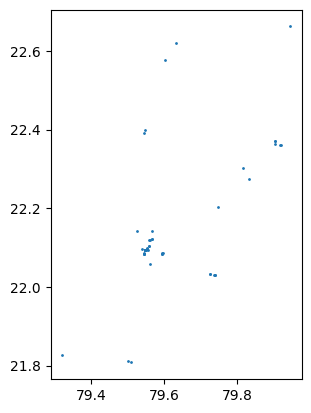

In [12]:
gdf.plot(markersize=1)

In [13]:
save_shapefiles(gdf, OUTPUT_DATA_DIR, "gov_buildings_new", formats=["parquet", "kml"])

In [14]:
gdf.head()

,S.No.,District,DISCOM,Name of Institutions/ Consumer,Govt. Dept. Name,IVRS/ Consumer Code,lat,lon,Average Monthly Electricity Consumption (kWh),Annual Consumption (kWh),...,Ownership a of Premises (Govt./ Private),Solar Rooftop Capacity (in kW) as per Contract Demand (C-1),Solar Rooftop Capacity (in kW) as per shadow free useful area of Consumer's Premise (C-2),Solar Rooftop Capacity (in kW) as per Monthly Consumption (C-3),Solar Rooftop Capacity (in kW) as per DTR Capacity (C-4),Rated Capacity of DTR (kVA),Solar Rooftop Capacity Installed/ Proposed to Install at concerned DTR (in kW),"Critical obseravation/ remarks, if any",Unnamed: 30,geometry
0,1.0,Seoni,MPPoKVVCL,"AE HOUSING BOARD JBP, CHHIDIYA PALARI, TRIBAL ...",Tribal Research and Development Institute (TRDI),1313046966,22.084803,79.594453,"7,950","95,400",...,Govt.,53.0,65.0,66.0,72.0,100,0.0,NaN,NaN,POINT (79.59445 22.08480)
1,2.0,Seoni,MPPoKVVCL,"ASSISTENT ENGINEER TESTING, 132 KV SUB STATION...",Transmission company,1412006481,22.102893,79.557736,"11,123","133,473",...,Govt.,65.0,79.0,93.0,144.0,200,0.0,NaN,NaN,POINT (79.55774 22.10289)
2,3.0,Seoni,MPPoKVVCL,"A E MPPKVV CO LTD, 132 KV SUBSTATION, SC 89279...",Transmission company,1121014415,22.620690,79.631206,"4,487","53,849",...,Govt.,50.0,61.0,37.0,18.0,25,0.0,NaN,NaN,POINT (79.63121 22.62069)
3,4.0,Seoni,MPPoKVVCL,"A.E. 220 KV SUB STATION, SIMARIYA, MPPKVV CO.L...",Transmission company,1313018680,22.141547,79.525387,"12,836","154,032",...,Govt.,50.0,61.0,107.0,18.0,25,0.0,NaN,NaN,POINT (79.52539 22.14155)
4,5.0,Seoni,MPPoKVVCL,"PRINCIPAL I T I, S C NO. 10701, INDUSTRIAL TEC...",Technical Education and Skill Development,1313039188,22.086900,79.595713,"1,196","14,357",...,Govt.,74.0,90.0,10.0,144.0,200,0.0,NaN,NaN,POINT (79.59571 22.08690)


## Clustering

In [15]:
from clustering import (
    build_graph_from_gdf_with_distance_threshold,
    get_connected_components_by_distance_threshold,
)

In [36]:
gdf_with_cluster_labels = gdf.copy().to_crs(INDIA_PROJECTED_CRS)
cluster_col_names = []

G = build_graph_from_gdf_with_distance_threshold(
    gdf_with_cluster_labels, distance_threshold=10_0000
)
thresholds = [1_000, 2_000, 3_000, 4_000, 5_000, 10_000, 20_000, 50_000]
threshold_names = ["1km", "2km", "3km", "4km", "5km", "10km", "20km", "50km"]

for threshold, threshold_str in zip(thresholds, threshold_names):
    cluster_col_name = f"cluster_id_{threshold_str}"
    cluster_col_names.append(cluster_col_name)

    cluster_labels_df, G_filtered_with_cluster_labels = (
        get_connected_components_by_distance_threshold(
            G,
            distance_threshold=threshold,
            cluster_id_col_name=cluster_col_name,
            cluster_id_prefix="SHAPE_",
        )
    )

    # add column to gdf based on index match
    gdf_with_cluster_labels[cluster_col_name] = gdf_with_cluster_labels.index.map(
        cluster_labels_df[cluster_col_name]
    )

Graph built with 52 nodes and 1323 edges.


In [37]:
def create_cluster_summary(gdf_with_cluster_labels, cluster_col_name="cluster"):
    """
    Create a summary GeoDataFrame of clusters with area and cost calculations.

    Args:
        gdf_with_cluster_labels: GeoDataFrame with cluster labels
        cluster_col_name: Name of the column containing cluster labels

    Returns:
        GeoDataFrame with cluster metrics
    """
    # Calculate building counts and create convex hulls
    building_counts = gdf_with_cluster_labels.groupby(cluster_col_name).size()
    hulls = gdf_with_cluster_labels.dissolve(cluster_col_name).convex_hull.buffer(20)

    # Create cluster summary DataFrame
    cluster_summary = gpd.GeoDataFrame(
        {"Building Count": building_counts, "geometry": hulls}, crs=INDIA_PROJECTED_CRS
    ).reset_index()

    # Rename cluster ID column
    cluster_summary = cluster_summary.rename(columns={cluster_col_name: "shape_id"})

    # Calculate derived metrics
    cluster_summary["Area (km²)"] = round(cluster_summary.area / 1_000_000, 4)
    cluster_summary["Charged Area (km²)"] = cluster_summary["Area (km²)"].apply(
        lambda x: 0.25 if x < 0.25 else x
    )
    cluster_summary["Charged Flight Time (hours)"] = round(
        cluster_summary["Charged Area (km²)"] / 0.25, 4
    )
    cluster_summary["Cost (INR)"] = round(
        cluster_summary["Charged Area (km²)"] * 18_000, 0
    )

    return cluster_summary

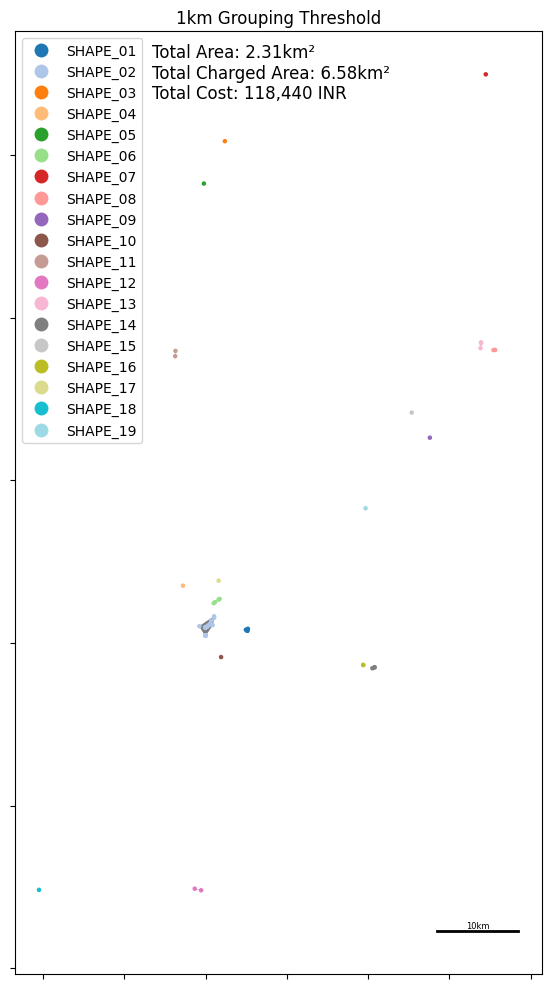

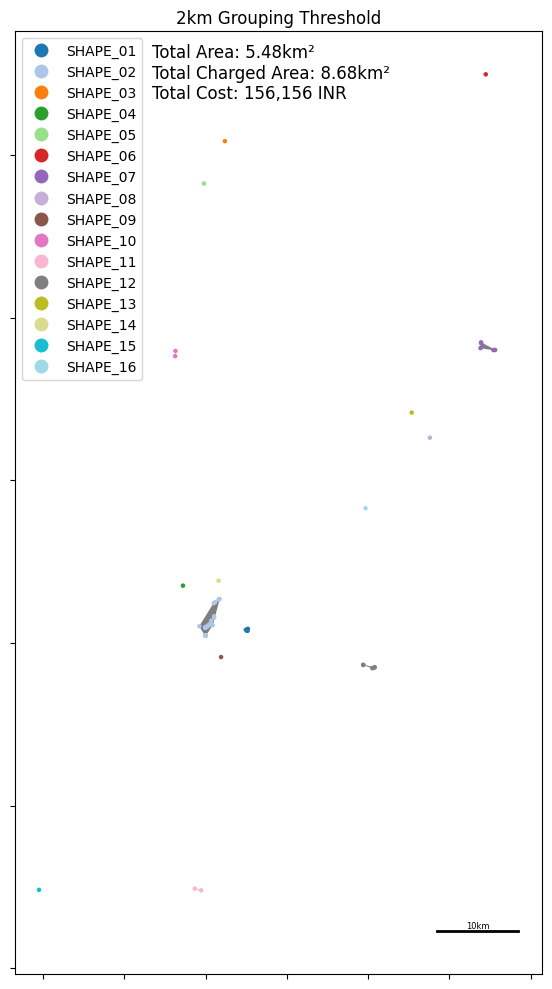

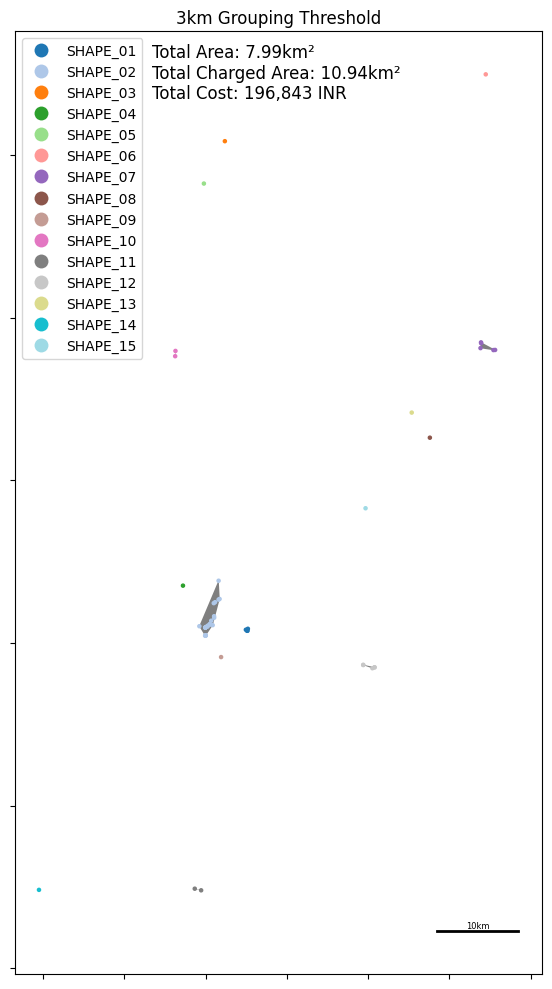

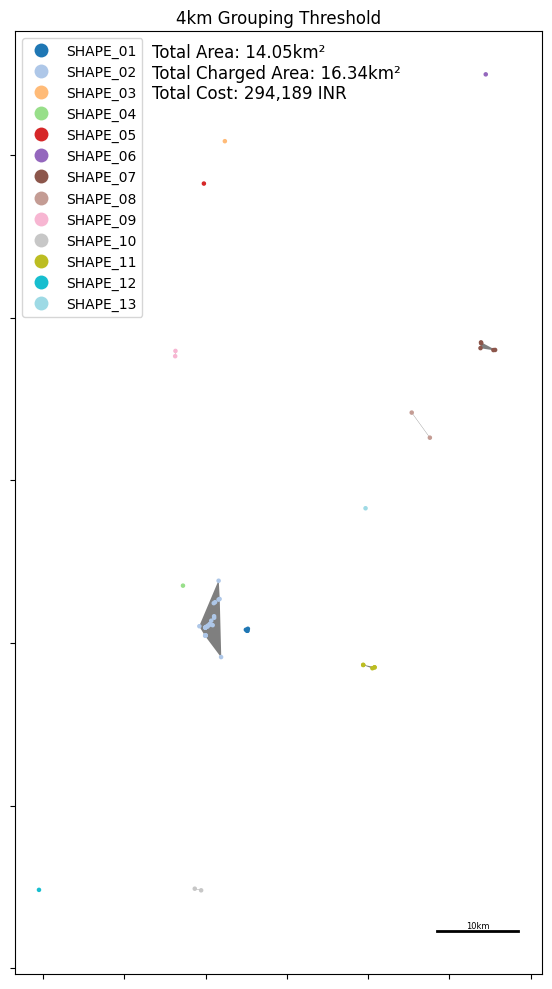

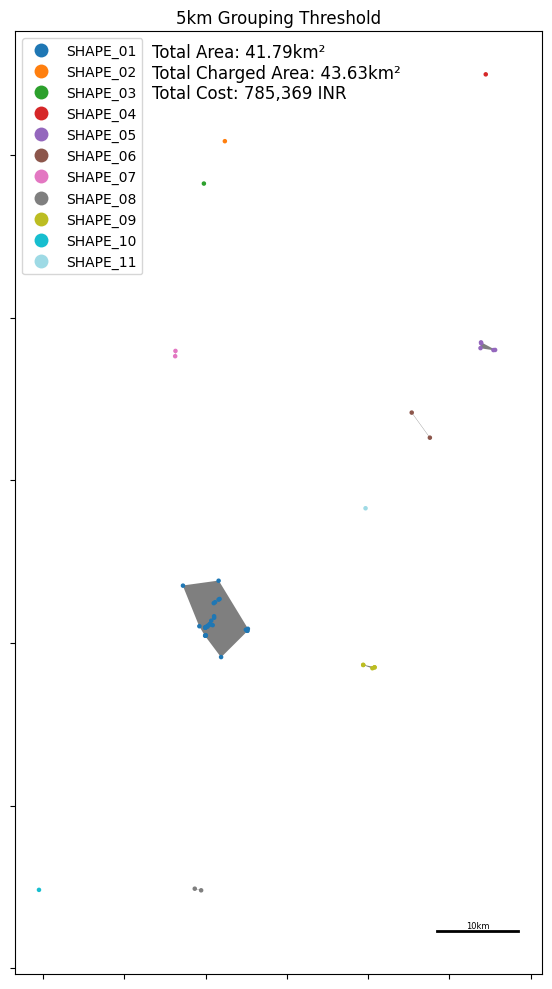

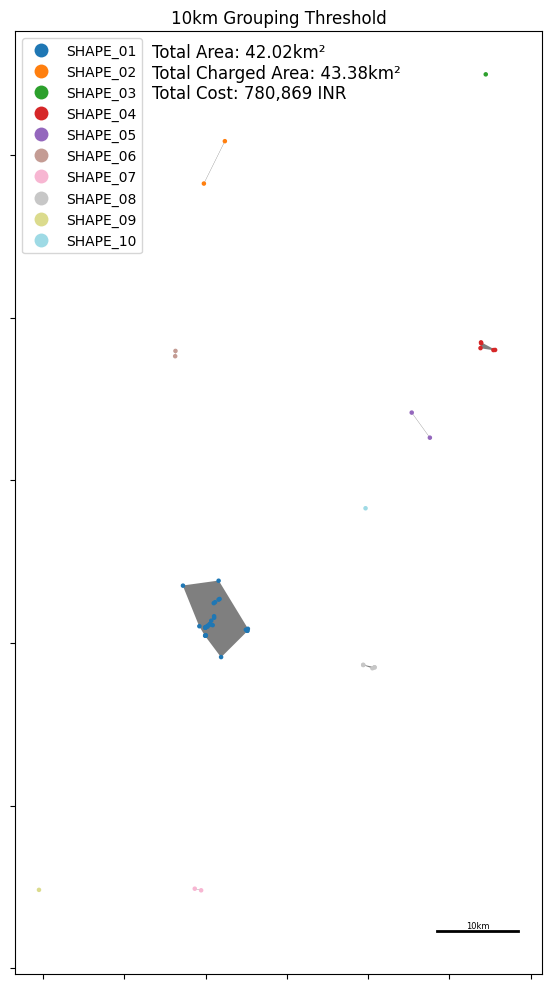

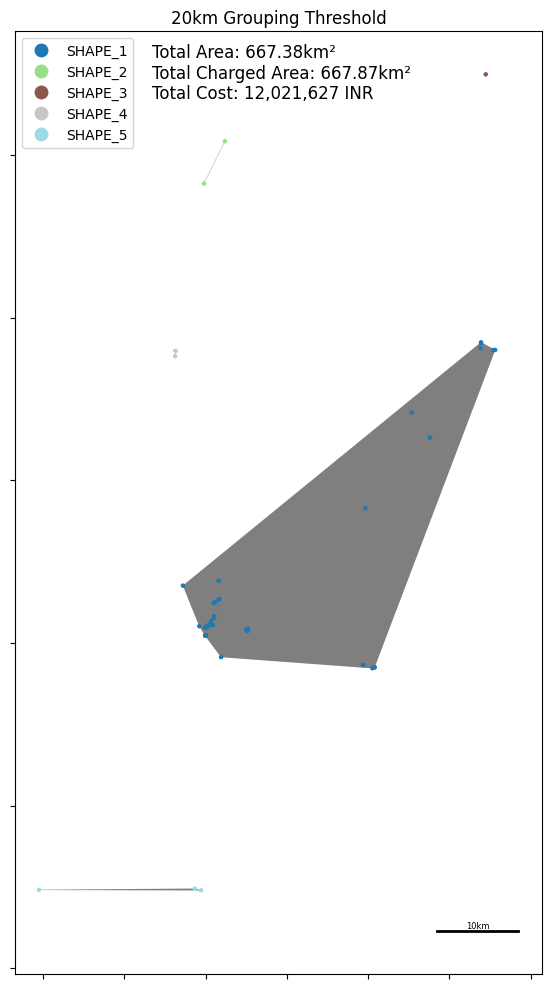

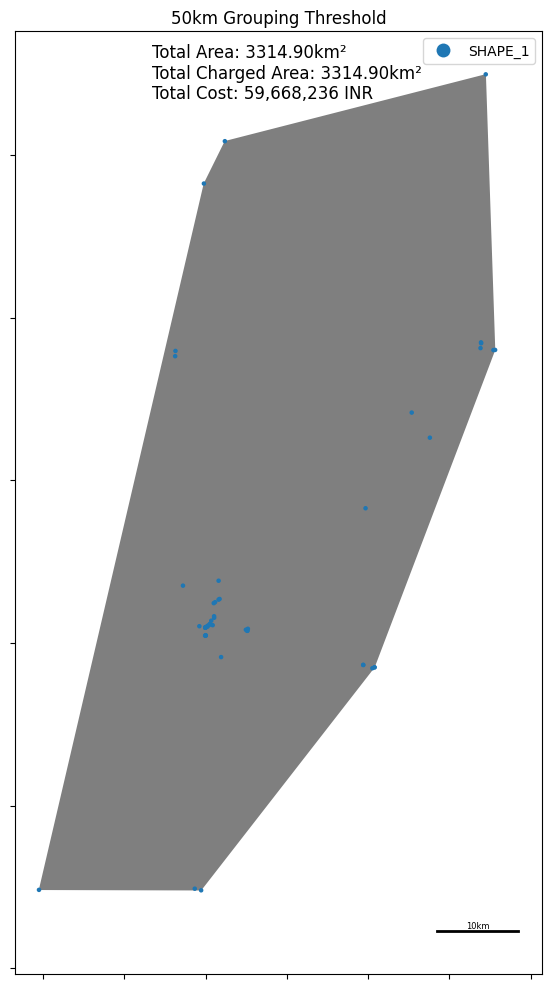

In [39]:
cluster_gdf_list = []

for threshold_str in threshold_names:
    cluster_col_name = f"cluster_id_{threshold_str}"

    cluster_gdf = create_cluster_summary(
        gdf_with_cluster_labels, cluster_col_name=cluster_col_name
    )
    cluster_gdf_list.append(cluster_gdf)

    # save to file
    save_shapefiles(
        cluster_gdf,
        OUTPUT_DATA_DIR / threshold_str,
        f"{threshold_str}_clusters_boundaries",
        formats=["csv", "kml"],
    )

    # Get all cluster columns except the current one
    cluster_cols_to_drop = [
        col_name for col_name in cluster_col_names if col_name != cluster_col_name
    ]
    save_shapefiles(
        gdf_with_cluster_labels.drop(columns=cluster_cols_to_drop),
        OUTPUT_DATA_DIR / threshold_str,
        f"{threshold_str}_cluster_buildings",
        formats=["csv", "kml"],
    )

    total_area = cluster_gdf["Area (km²)"].sum()
    totla_charged_area = cluster_gdf["Charged Area (km²)"].sum()
    total_cost = cluster_gdf["Cost (INR)"].sum()

    ax = cluster_gdf.plot(
        figsize=(10, 10),
        color="black",
        alpha=0.5,
    )

    gdf_with_cluster_labels.plot(
        ax=ax,
        column=cluster_col_name,
        cmap="tab20",
        markersize=5,
        legend=True,
    )

    # add a 1km line to show scale on the plot
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    length = 10000
    length_name = "10km"
    ax.plot(
        [xmax - length, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-"
    )
    ax.plot(
        [xmax - length, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-"
    )
    ax.text(xmax - length / 2, ymin + 400, length_name, fontsize=6, ha="center")

    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(f"{threshold_str} Grouping Threshold")

    # add text to show total area and cost
    ax.text(
        xmax - 45000,
        ymax - 8000,
        (
            f"Total Area: {total_area:.2f}km²\n"
            f"Total Charged Area: {totla_charged_area:.2f}km²\n"
            f"Total Cost: {total_cost:,.0f} INR"
        ),
        fontsize=12,
        ha="left",
    )
    # remove extra white space in saved file
    plt.tight_layout()
    plt.savefig(OUTPUT_DATA_DIR / f"clustered_buildings_{threshold_str}.png", dpi=300)
    plt.show()

    # cluster_areas.hist(bins=50)
    # plt.title(f"{threshold_str} Threshold")
    # plt.show()

In [58]:
# concatenate the cluster_gdf_list with the threshold names added
all_groupings_gdf = pd.concat(
    [cluster_gdf.assign(threshold=threshold) for cluster_gdf, threshold in zip(cluster_gdf_list, threshold_names)]
)

In [59]:
# make a summary of the total area total charged area and cost and total number of shapes for each threshold
threshold_summary = all_groupings_gdf.groupby("threshold").agg(
    {
        "Area (km²)": "sum",
        "Charged Area (km²)": "sum",
        "Cost (INR)": "sum",
        "shape_id": "count",
    }
)

In [60]:
# sort values by threshold ID but make sure we order correctly by the numbers not 10, 1, 20, 2 etc
threshold_summary = threshold_summary.reset_index()
threshold_summary["threshold"] = pd.Categorical(threshold_summary["threshold"], threshold_names)
threshold_summary = threshold_summary.sort_values("threshold")

In [61]:
# round areas to 2 decimal places and cost as int
threshold_summary["Area (km²)"] = threshold_summary["Area (km²)"].round(2)
threshold_summary["Charged Area (km²)"] = threshold_summary["Charged Area (km²)"].round(2)
threshold_summary["Cost (INR)"] = threshold_summary["Cost (INR)"].astype(int)
# drop rename shape_id to Number of Shapes
threshold_summary = threshold_summary.rename(columns={"shape_id": "Number of Shapes"})

In [62]:
threshold_summary

,threshold,Area (km²),Charged Area (km²),Cost (INR),Number of Shapes
1,1km,2.31,6.58,118440,19
3,2km,5.48,8.68,156156,16
4,3km,7.99,10.94,196843,15
5,4km,14.05,16.34,294189,13
7,5km,41.79,43.63,785369,11
0,10km,42.02,43.38,780869,10
2,20km,667.38,667.87,12021627,5
6,50km,3314.90,3314.90,59668236,1


In [63]:
# Display the pivot table
threshold_summary.to_csv(OUTPUT_DATA_DIR / "cluster_stats.csv", index=False)

In [ ]:
# # cluster with kmeans
# from sklearn.cluster import KMeans

# kmeans = KMeans(n_clusters=8, random_state=0)
# gdf["cluster"] = [str(i) for i in kmeans.fit_predict(gdf[["lon", "lat"]])]
# gdf.plot(column="cluster", markersize=1, legend=True)

In [ ]:
# from sklearn.cluster import HDBSCAN

# dbscan = HDBSCAN(n_jobs=-1)
# gdf["cluster"] = dbscan.fit_predict(gdf[["lon", "lat"]])
# gdf.plot(column="cluster", markersize=1, legend=True)

## Travelling Salesman

In [ ]:
gdf_projected = gdf.to_crs("EPSG:24378")

In [ ]:
gdf_projected.lat = gdf_projected.geometry.y
gdf_projected.lon = gdf_projected.geometry.x

In [ ]:
from scipy.spatial import distance_matrix

# Calculate the distance matrix
dist_matrix = distance_matrix(gdf_projected[["lon", "lat"]], gdf_projected[["lon", "lat"]])

In [ ]:
from ortools.constraint_solver import pywrapcp
from ortools.constraint_solver import routing_enums_pb2

In [ ]:
# make list of latlon tuples
lonlat = [(lon, lat) for lon, lat in zip(gdf_projected.lon, gdf_projected.lat)]

In [ ]:
from scipy.spatial import distance_matrix
from ortools.constraint_solver import pywrapcp
from ortools.constraint_solver import routing_enums_pb2

# Coordinates example
coordinates = lonlat

# Distance matrix
dist_matrix = distance_matrix(coordinates, coordinates)

def create_data_model():
    return {'distance_matrix': dist_matrix, 'num_locations': len(coordinates)}

data = create_data_model()
manager = pywrapcp.RoutingIndexManager(data['num_locations'], 1, 0)
routing = pywrapcp.RoutingModel(manager)

def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return int(data['distance_matrix'][from_node][to_node])

transit_callback_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)
search_parameters.local_search_metaheuristic = (
    routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH)
search_parameters.time_limit.seconds = 30

solution = routing.SolveWithParameters(search_parameters)

In [ ]:
# Print the solution (ordered route)
if solution:
    index = routing.Start(0)
    route = []
    while not routing.IsEnd(index):
        route.append(manager.IndexToNode(index))
        index = solution.Value(routing.NextVar(index))
    route.append(manager.IndexToNode(index))
    print("Optimal Path:", route)

In [ ]:
# make a multi-line string
from shapely.geometry import LineString

In [ ]:
line_gdf = gpd.GeoDataFrame(
    data={"start_index": route[:-1], "end_index": route[1:]},
    geometry=[
        LineString(
            [
                gdf_projected.iloc[route[i]].geometry,
                gdf_projected.iloc[route[i + 1]].geometry,
            ]
        )
        for i in range(len(route) - 1)
    ],
)

In [ ]:
line_gdf

In [ ]:
# add start and end cluster names
line_gdf["start_cluster"] = gdf_projected.iloc[line_gdf.start_index].cluster.values
line_gdf["end_cluster"] = gdf_projected.iloc[line_gdf.end_index].cluster.values

In [ ]:
filtered_line_gdf = line_gdf[line_gdf["start_cluster"] == line_gdf["end_cluster"]]

In [ ]:
filtered_line_gdf.length.sum()

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))
gdf_projected.plot(ax=ax, column="cluster", markersize=35)
# line_gdf.plot(ax=ax)
filtered_line_gdf.plot(ax=ax, color="black")

# add a 1km line to show scale on the plot
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
length = 10000
length_name = "10km"
ax.plot([xmax - length, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
ax.plot([xmax - length, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
ax.text(xmax - length/2, ymin + 400, length_name, fontsize=6, ha="center")

# axes off
ax.axis("off")

In [ ]:
flight_paths_gdf = filtered_line_gdf.dissolve("start_cluster").reset_index()[["start_cluster", "geometry"]]
flight_paths_gdf.rename(columns={"start_cluster": "cluster"}, inplace=True)
flight_paths_gdf.set_crs("EPSG:24378", inplace=True)

In [ ]:
# get count of buildings in each cluster
n_buildings_per_cluster = gdf_projected.groupby("cluster").size()
flight_paths_gdf["Number of Buildings"] = flight_paths_gdf["cluster"].map(n_buildings_per_cluster)

In [ ]:
flight_paths_gdf["Length (km)"] = round(flight_paths_gdf.length / 1000, 2)

In [ ]:
line_gdf[line_gdf["start_cluster"] != line_gdf["end_cluster"]].length

In [ ]:
save_shapefiles(
    flight_paths_gdf.to_crs("EPSG:4326"),
    OUTPUT_DATA_DIR,
    "flight_paths_grouped",
    formats=["parquet", "kml"],
)

In [ ]:
save_shapefiles(
    gdf.to_crs("EPSG:4326"),
    OUTPUT_DATA_DIR,
    "gov_buildings_grouped",
    formats=["parquet", "kml"],
)

In [ ]:
flight_path_buffered_gdf = flight_paths_gdf.copy()
flight_path_buffered_gdf["geometry"] = flight_path_buffered_gdf.buffer(50)

save_shapefiles(
    flight_path_buffered_gdf.to_crs("EPSG:4326"),
    OUTPUT_DATA_DIR,
    "flight_paths_grouped_buffered",
    formats=["parquet", "kml"],
)